# 10 — Split-Aware EDA and Outlier Analysis

This notebook is the governed Step 9A inspection surface. It now pairs the
underlying evidence tables with inline charts so class balance, temporal
patterns, missingness, categorical behavior, outliers, and split drift are
visually interpretable. Training remains the sole feature-discovery authority;
validation and test visuals are restricted to structural disclosure.


In [3]:
from pathlib import Path

import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))


from urban_ops.eda.notebook_visuals import (
    plot_cardinality,
    plot_categorical_target_rate,
    plot_day_of_week,
    plot_hour_of_day,
    plot_missingness_by_target,
    plot_missingness_over_time,
    plot_monthly_target_rate,
    plot_monthly_volume,
    plot_numeric_by_target,
    plot_numeric_drift,
    plot_outlier_diagnostics,
    plot_period_patterns,
    plot_recommendation_decisions,
    plot_split_missingness,
    plot_split_target_rate,
    plot_target_distribution,
    plot_training_missingness,
    plot_unseen_categories,
)
from urban_ops.eda.pipeline import run_split_aware_eda
from urban_ops.eda.source import verify_source_unchanged


# Restore the inline backend after the report pipeline configures headless PNG output.
get_ipython().run_line_magic('matplotlib', 'inline')


CONFIG_PATH = PROJECT_ROOT / 'configs/eda/resolution_risk.yaml'
PUBLISH_EDA_REPORTS = False
result = run_split_aware_eda(config_path=CONFIG_PATH, dry_run=not PUBLISH_EDA_REPORTS)
TABLES = result.tables
pd.Series({'split_id': result.source.split_id, 'published': not result.dry_run})


split_id     20260806T135114Z_9d945cb2da0eecfc
published                                False
dtype: object

## 2. Source split authority
The latest pointer or an explicit override is resolved; directory ordering is never used.

In [4]:
TABLES['source_split_verification.csv']

,artifact_name,artifact_path,sha256,expected_sha256,mtime_ns,row_count,expected_row_count,status,split_id
0,train,/Users/mohammadmubashir/VCode/urban-operations...,b9548bfb647445c13afcc640091bb006dbd32eaead4dd1...,b9548bfb647445c13afcc640091bb006dbd32eaead4dd1...,1786024274599539142,23699,23699,PASS,20260806T135114Z_9d945cb2da0eecfc
1,validation,/Users/mohammadmubashir/VCode/urban-operations...,fd8c6f7da014c4093861c4a6ac69586bf5de11e92b66a2...,fd8c6f7da014c4093861c4a6ac69586bf5de11e92b66a2...,1786024274646007539,6762,6762,PASS,20260806T135114Z_9d945cb2da0eecfc
2,test,/Users/mohammadmubashir/VCode/urban-operations...,c07564393676c64b7f7f7a7fd14b71023706b48bfcfd81...,c07564393676c64b7f7f7a7fd14b71023706b48bfcfd81...,1786024274674913571,5499,5499,PASS,20260806T135114Z_9d945cb2da0eecfc
3,metadata,/Users/mohammadmubashir/VCode/urban-operations...,5f925842c18a8b4e709d451c20a7e8649ddbad67f56df0...,5f925842c18a8b4e709d451c20a7e8649ddbad67f56df0...,1786024274740180021,<NA>,<NA>,PASS,20260806T135114Z_9d945cb2da0eecfc
4,rules_snapshot,/Users/mohammadmubashir/VCode/urban-operations...,9d945cb2da0eecfce9d45b1210e68613b2231a4d3d2941...,9d945cb2da0eecfce9d45b1210e68613b2231a4d3d2941...,1786024274686118232,<NA>,<NA>,PASS,20260806T135114Z_9d945cb2da0eecfc
5,latest_pointer,/Users/mohammadmubashir/VCode/urban-operations...,1d1ded39e96e935579a6c4c2cb619d1d300babb9fbe060...,1d1ded39e96e935579a6c4c2cb619d1d300babb9fbe060...,1786024289173521668,<NA>,<NA>,PASS,20260806T135114Z_9d945cb2da0eecfc


## 3. Source integrity verification

In [5]:
TABLES['eda_integrity_checks.csv']

,check_id,area,status,observed_value,expected_value,affected_rows,message
0,source.rows_reconcile,source,PASS,35960,35960,0,"Train, validation, and test rows reconcile wit..."
1,source.schemas_equal,source,PASS,True,True,0,All split schemas are identical.
2,source.target_binary_non_null,target,PASS,"[0, 1]","{0,1} with no nulls",0,Governed target remains binary and complete.
3,temporal.created_hour_domain,temporal,PASS,0,0,0,"created_hour stays within [0, 23]."
4,temporal.created_day_of_week_domain,temporal,PASS,0,0,0,"created_day_of_week stays within [0, 6]."
5,temporal.created_day_of_month_domain,temporal,PASS,0,0,0,"created_day_of_month stays within [1, 31]."
6,temporal.created_week_of_year_domain,temporal,PASS,0,0,0,"created_week_of_year stays within [1, 53]."
7,temporal.created_month_domain,temporal,PASS,0,0,0,"created_month stays within [1, 12]."
8,temporal.created_quarter_domain,temporal,PASS,0,0,0,"created_quarter stays within [1, 4]."
9,temporal.is_weekend_domain,temporal,PASS,True,True,0,Weekend derivation is boolean.


## 4. Train/validation/test governance
Train governs discovery and recommendations. Validation and test provide structural disclosure only; test findings cannot select features, transformations, thresholds, or models.

In [6]:
TABLES['split_target_comparison.csv']

,split_name,row_count,on_time_count,missed_count,missed_target_rate,governance_use
0,train,23699,12792,10907,0.460230,feature discovery authority
1,validation,6762,3880,2882,0.426205,structural disclosure only; not feature selection
2,test,5499,3572,1927,0.350427,structural disclosure only; not feature selection


## 5. Column inventory and feature roles

In [7]:
TABLES['column_inventory.csv'][['column_name','feature_role','leakage_status','variance_status','eda_treatment']]

,column_name,feature_role,leakage_status,variance_status,eda_treatment
0,unique_key,IDENTIFIER,BLOCKED,HAS_VARIATION,DESCRIBE_ONLY
1,created_date,SAFE_CANDIDATE,SAFE,HAS_VARIATION,PROFILE_FOR_RECOMMENDATION
2,closed_date,BLOCKED_LEAKAGE,BLOCKED,HAS_VARIATION,DESCRIBE_ONLY
3,due_date,BLOCKED_LEAKAGE,BLOCKED,HAS_VARIATION,DESCRIBE_ONLY
4,agency,ZERO_VARIANCE,SAFE,ZERO_VARIANCE,PROFILE_FOR_RECOMMENDATION
5,agency_name,ZERO_VARIANCE,SAFE,ZERO_VARIANCE,PROFILE_FOR_RECOMMENDATION
6,complaint_type,ZERO_VARIANCE,SAFE,ZERO_VARIANCE,PROFILE_FOR_RECOMMENDATION
7,descriptor,ZERO_VARIANCE,CONDITIONAL,ZERO_VARIANCE,PROFILE_FOR_RECOMMENDATION
8,descriptor_2,ALL_NULL,CONDITIONAL,ALL_NULL,PROFILE_FOR_RECOMMENDATION
9,status,BLOCKED_LEAKAGE,BLOCKED,ZERO_VARIANCE,DESCRIBE_ONLY


## 6. Training target distribution

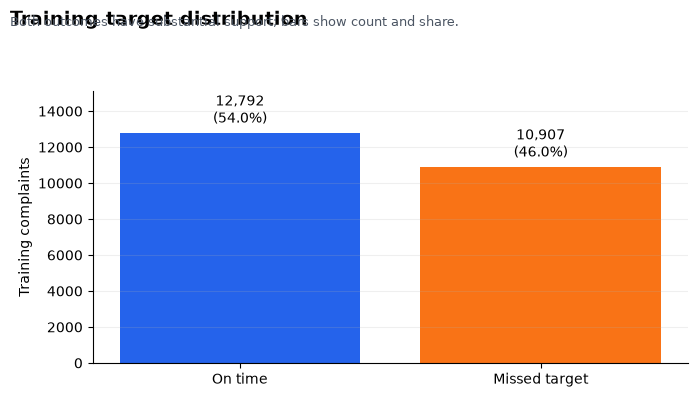

,on_time_count,missed_count,total_count,on_time_share,missed_target_rate,class_ratio_missed_to_on_time,majority_class,majority_class_accuracy,constant_probability_baseline,class_weighting_recommendation
0,12792,10907,23699,0.53977,0.46023,0.852642,0,0.53977,0.46023,EXPERIMENT_NOT_AUTOMATIC; both classes have su...


In [8]:
display(plot_target_distribution(TABLES))
plt.close()
TABLES['train_target_distribution.csv']


### Interpretation

The training target is **reasonably balanced**.

- **On-time complaints:** 12,792 (53.98%)
- **Missed-target complaints:** 10,907 (46.02%)
- **Missed-to-on-time class ratio:** approximately 0.85

The difference between the two classes is about 8 percentage points, so this is not a severe class-imbalance problem.

For the initial baseline models:

- Do not apply SMOTE, undersampling, or oversampling automatically.
- Start with the original training distribution.
- Treat `class_weight="balanced"` as an experiment to compare, not as a requirement.
- Do not rely on accuracy alone because a majority-class predictor would already achieve approximately 53.98% accuracy.
- Evaluate the models using ROC-AUC, PR-AUC, precision, recall, F1, log loss, Brier score, and calibration.

**EDA decision:** The target distribution does not require mandatory resampling or class weighting before baseline modelling.

### `class_weight=None` vs `class_weight="balanced"`

Both settings keep the original training sample unchanged.

The training data remains:

- **On-time complaints:** 12,792 (53.98%)
- **Missed-target complaints:** 10,907 (46.02%)
- **Total training rows:** 23,699

Neither option adds, removes, copies, or synthetically generates rows.

#### `class_weight=None`

With:

```python
LogisticRegression(class_weight=None)
```

each training row contributes equally to the model's loss.

Conceptually:

```text
On-time row weight:       1.0
Missed-target row weight: 1.0
```

This should be used as the primary logistic-regression baseline because the target classes are already reasonably balanced.

#### `class_weight="balanced"`

With:

```python
LogisticRegression(class_weight="balanced")
```

the model automatically gives slightly more importance to the smaller class and slightly less importance to the larger class.

Scikit-learn calculates the class weight using:

```text
class weight =
total training rows / (number of classes × rows in that class)
```

For this training set, the approximate weights are:

```text
On-time class:       0.93
Missed-target class: 1.09
```

This means an error on a missed-target complaint receives a slightly larger training penalty than an error on an on-time complaint.

The sample distribution itself does not change.

#### Expected trade-off

Compared with `class_weight=None`, the balanced model may produce:

- higher missed-target recall;
- fewer false negatives;
- more missed-target predictions;
- lower precision;
- more false positives;
- possibly weaker probability calibration.

Because the original distribution is only 53.98% versus 46.02%, the difference between the two models may be modest.

#### Baseline decision

Use:

```python
LogisticRegression(class_weight=None)
```

as the primary baseline.

Also run:

```python
LogisticRegression(class_weight="balanced")
```

as a controlled comparison in the baseline-modelling notebook.

Fit both models on the training split using identical preprocessing and compare them on the validation split using:

- precision;
- recall;
- F1;
- false positives;
- false negatives;
- ROC-AUC;
- PR-AUC;
- log loss;
- Brier score;
- probability calibration.

Do not select the balanced model automatically. Prefer it only when validation results show a meaningful improvement in detecting missed-target complaints and the increase in false positives or deterioration in probability quality remains acceptable.

**Notebook 10 decision:** recommend comparing both settings later; do not fit either model in this EDA notebook.

## 7. Temporary creation-time feature derivation

Calendar fields are derived only in the pipeline's in-memory EDA copy.
`baseline_decision` remains the existing handoff field. The `eda_status`
values below are EDA eligibility statuses for later testing, not final
model-selection decisions.

### How temporal feature statuses are assigned

Notebook 10 does not make the final model-selection decision.

The statuses below describe whether a derived temporal field is eligible, redundant, risky, or still unresolved after train-only EDA.

The status-assignment order is:

1. If the feature is unavailable at prediction time, mark it `EXCLUDE` or `CONDITIONAL`.
2. If the feature leaks the outcome, mark it `EXCLUDE`.
3. If the feature is all-null or has zero variance, mark it `EXCLUDE`.
4. If it is an exact one-to-one representation of another preferred feature, mark it `ALTERNATIVE_REPRESENTATION`.
5. If it overlaps strongly with another feature but is not an exact duplicate, mark it `REVIEW_REDUNDANCY`.
6. If it introduces temporal-generalization or other unresolved risk, mark it `CONDITIONAL`.
7. If it is creation-time safe, valid, variable, interpretable, and sufficiently supported, mark it `CANDIDATE`.
8. If the available evidence is insufficient, mark it `REVIEW`.

A `CANDIDATE` status means the feature is reasonable to test later. It does not mean the feature is guaranteed to enter the final model.

In [9]:
TABLES['baseline_feature_recommendation.csv'].query(
    "source_column == 'created_date' or feature_name == 'created_date'"
)[[
    'feature_name',
    'derivation_rule',
    'prediction_time_available',
    'variation_status',
    'redundancy_status',
    'temporal_risk',
    'eda_status',
    'status_reason',
]]

,feature_name,derivation_rule,prediction_time_available,variation_status,redundancy_status,temporal_risk,eda_status,status_reason
1,created_date,source value unchanged,True,HAS_VARIATION,NONE,LONG_TERM_PROGRESSION,REVIEW,Raw timestamp is not directly model-ready and ...
44,created_hour,derive from created_date,True,HAS_VARIATION,NONE,NONE,CANDIDATE,"Creation-time safe, valid, interpretable, and ..."
45,created_day_of_week,derive from created_date,True,HAS_VARIATION,NONE,NONE,CANDIDATE,Creation-time safe and the preferred machine-f...
46,created_day_name,derive from created_date,True,HAS_VARIATION,EXACT_ALTERNATIVE_OF:created_day_of_week,NONE,ALTERNATIVE_REPRESENTATION,Exact human-readable representation of created...
47,created_day_of_month,derive from created_date,True,HAS_VARIATION,NONE,NONE,REVIEW,Creation-time safe but operational usefulness ...
48,created_week_of_year,derive from created_date,True,HAS_VARIATION,OVERLAPPING_SEASONAL,NONE,REVIEW_REDUNDANCY,Seasonal representation that overlaps strongly...
49,created_month,derive from created_date,True,HAS_VARIATION,NONE,NONE,CANDIDATE,Preferred interpretable seasonal candidate.
50,created_month_name,derive from created_date,True,HAS_VARIATION,EXACT_ALTERNATIVE_OF:created_month,NONE,ALTERNATIVE_REPRESENTATION,Exact human-readable representation of created...
51,created_quarter,derive from created_date,True,HAS_VARIATION,OVERLAPPING_SEASONAL,NONE,REVIEW_REDUNDANCY,Coarser seasonal representation that overlaps ...
52,created_year,derive from created_date,True,HAS_VARIATION,NONE,TEMPORAL_GENERALIZATION,CONDITIONAL,Technically available at creation time but may...


### Interpretation

These fields were created only in the in-memory EDA working copy so their patterns could be evaluated.

They have not been written back to the split files, fitted through a transformer, added to a feature matrix, or used to train a model.

The preferred first-pass temporal candidates are:

- `created_hour`
- `created_day_of_week`
- `created_month`
- `is_weekend`

The following fields represent alternative or overlapping versions of the same temporal information:

- `created_day_name`
- `created_month_name`
- `created_week_of_year`
- `created_quarter`

`created_year` remains conditional because it may act as a shortcut for temporal drift rather than a stable operational pattern.

Notebook 11 must make the formal feature-construction and encoding decision, and Notebook 12 must determine whether each approved representation improves validation performance.

## 8. Monthly complaint volume

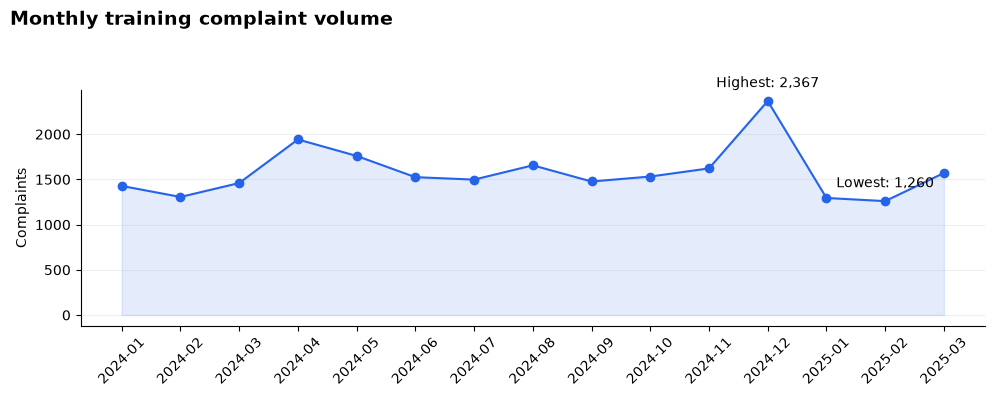

,month,row_count,minimum_created_date,maximum_created_date,row_share,month_to_month_count_change,month_to_month_count_pct_change,support_flag
0,2024-01,1428,2024-01-01 07:58:15+00:00,2024-01-31 20:37:42+00:00,0.060256,NaN,NaN,SUPPORTED
1,2024-02,1306,2024-02-01 01:33:06+00:00,2024-02-29 23:08:25+00:00,0.055108,-122.0,-0.085434,SUPPORTED
2,2024-03,1460,2024-03-01 07:41:14+00:00,2024-03-31 23:53:43+00:00,0.061606,154.0,0.117917,SUPPORTED
3,2024-04,1942,2024-04-01 05:04:10+00:00,2024-04-30 23:41:30+00:00,0.081944,482.0,0.330137,SUPPORTED
4,2024-05,1760,2024-05-01 00:31:38+00:00,2024-05-31 23:56:44+00:00,0.074265,-182.0,-0.093718,SUPPORTED
5,2024-06,1525,2024-06-01 00:13:24+00:00,2024-06-30 20:45:13+00:00,0.064349,-235.0,-0.133523,SUPPORTED
6,2024-07,1498,2024-07-01 00:37:05+00:00,2024-07-31 23:44:24+00:00,0.063209,-27.0,-0.017705,SUPPORTED
7,2024-08,1656,2024-08-01 06:15:14+00:00,2024-08-31 22:28:45+00:00,0.069876,158.0,0.105474,SUPPORTED
8,2024-09,1477,2024-09-01 01:38:44+00:00,2024-09-30 23:15:27+00:00,0.062323,-179.0,-0.108092,SUPPORTED
9,2024-10,1532,2024-10-01 07:56:36+00:00,2024-10-31 22:27:48+00:00,0.064644,55.0,0.037238,SUPPORTED


In [10]:
display(plot_monthly_volume(TABLES))
plt.close()
TABLES['monthly_volume.csv']


## 9. Monthly missed-target rate

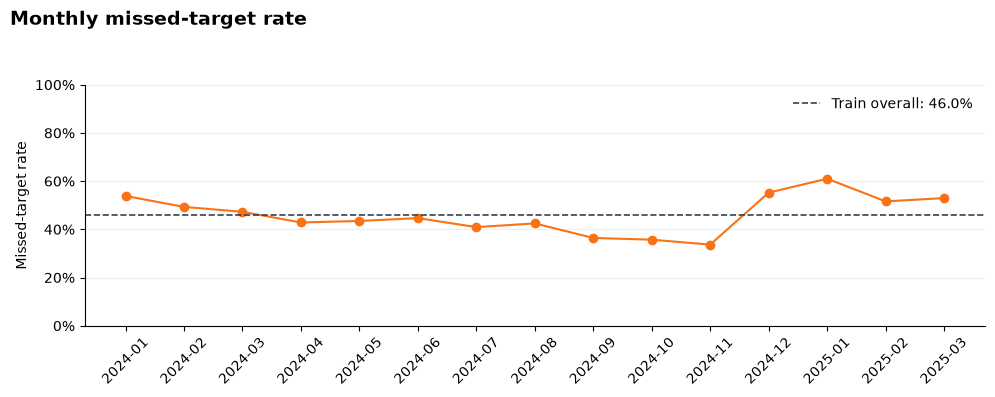

,month,row_count,missed_count,on_time_count,missed_target_rate,overall_train_rate,rate_difference_from_train,month_to_month_rate_change,support_flag
0,2024-01,1428,769,659,0.538515,0.46023,0.078285,<NA>,SUPPORTED
1,2024-02,1306,644,662,0.493109,0.46023,0.032878,-0.045407,SUPPORTED
2,2024-03,1460,690,770,0.472603,0.46023,0.012372,-0.020506,SUPPORTED
3,2024-04,1942,832,1110,0.428424,0.46023,-0.031806,-0.044178,SUPPORTED
4,2024-05,1760,765,995,0.434659,0.46023,-0.025571,0.006235,SUPPORTED
5,2024-06,1525,681,844,0.446557,0.46023,-0.013673,0.011898,SUPPORTED
6,2024-07,1498,613,885,0.409212,0.46023,-0.051018,-0.037345,SUPPORTED
7,2024-08,1656,703,953,0.424517,0.46023,-0.035713,0.015305,SUPPORTED
8,2024-09,1477,538,939,0.364252,0.46023,-0.095979,-0.060265,SUPPORTED
9,2024-10,1532,547,985,0.35705,0.46023,-0.103181,-0.007202,SUPPORTED


In [11]:
display(plot_monthly_target_rate(TABLES))
plt.close()
TABLES['monthly_target_rate.csv']


## 10. Day-of-week patterns

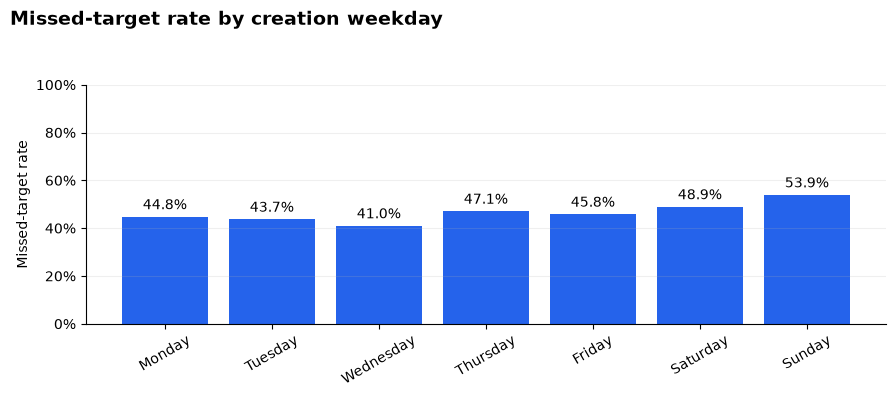

,day_order,created_day_name,row_count,missed_count,on_time_count,missed_target_rate
0,0,Monday,3521,1577,1944,0.447884
1,1,Tuesday,3330,1456,1874,0.437237
2,2,Wednesday,3906,1601,2305,0.409882
3,3,Thursday,4226,1990,2236,0.470894
4,4,Friday,3570,1636,1934,0.458263
5,5,Saturday,2566,1256,1310,0.489478
6,6,Sunday,2580,1391,1189,0.539147


In [12]:
display(plot_day_of_week(TABLES))
plt.close()
TABLES['day_of_week_target_rate.csv']


## 11. Hour-of-day patterns

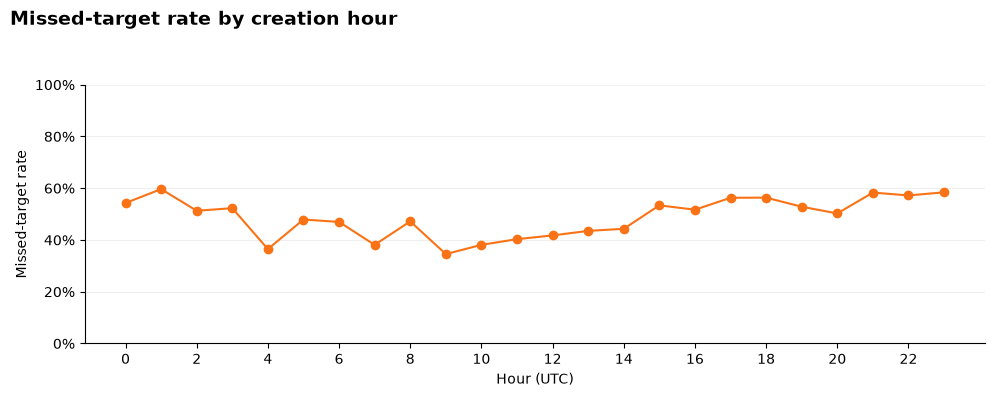

,created_hour,row_count,missed_count,on_time_count,missed_target_rate
0,0,315,171,144,0.542857
1,1,419,250,169,0.596659
2,2,232,119,113,0.512931
3,3,109,57,52,0.522936
4,4,244,89,155,0.364754
5,5,311,149,162,0.4791
6,6,711,334,377,0.469761
7,7,1225,467,758,0.381224
8,8,1193,563,630,0.47192
9,9,1777,614,1163,0.345526


In [13]:
display(plot_hour_of_day(TABLES))
plt.close()
TABLES['hour_of_day_target_rate.csv']


## 12. Quarter, year, and weekend patterns

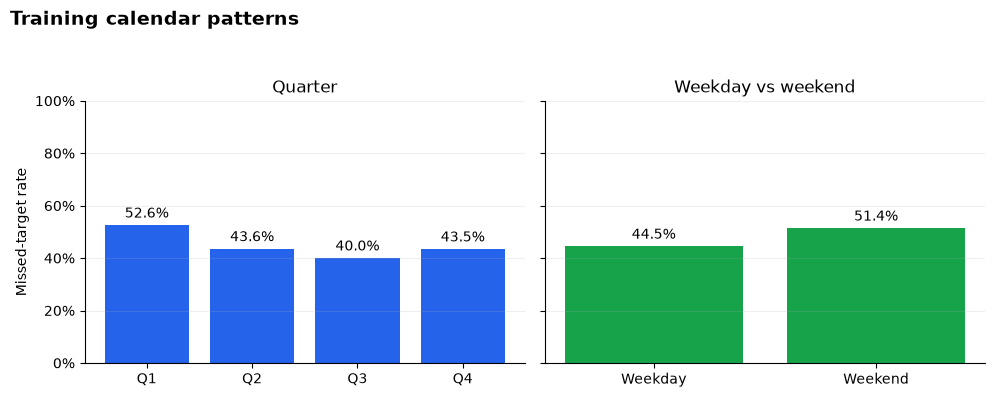

,created_quarter,row_count,missed_count,on_time_count,missed_target_rate
0,1,8320,4375,3945,0.525841
1,2,5227,2278,2949,0.435814
2,3,4631,1854,2777,0.400345
3,4,5521,2400,3121,0.434704


,is_weekend,row_count,missed_count,on_time_count,missed_target_rate
0,False,18553,8260,10293,0.445211
1,True,5146,2647,2499,0.51438


In [14]:
display(plot_period_patterns(TABLES))
plt.close()
display(TABLES['quarterly_target_rate.csv'])
display(TABLES['weekend_target_rate.csv'])


## 13. Training missingness

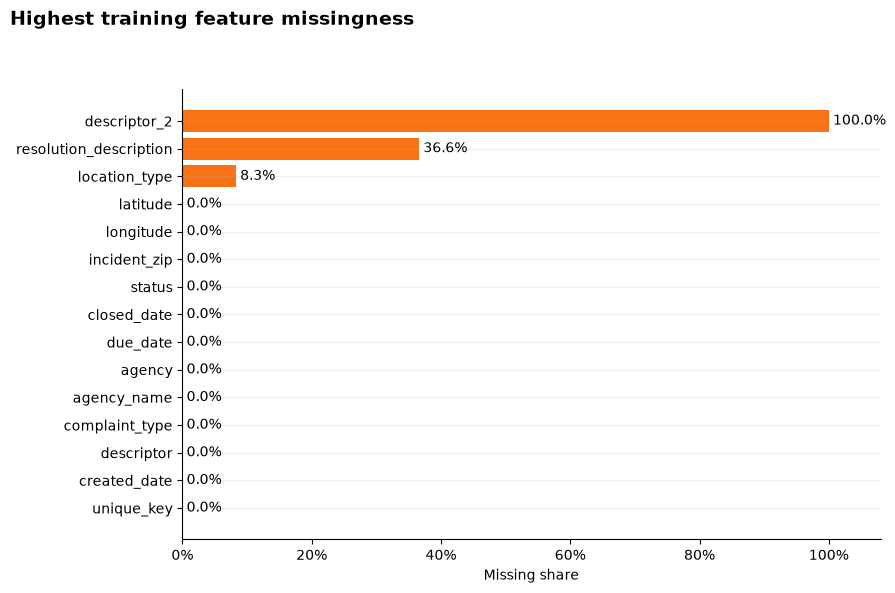

,column_name,missing_count,missing_rate,non_null_count,missingness_band
8,descriptor_2,23699,1.000000,0,ALL_NULL
16,resolution_description,8680,0.366260,15019,HIGH
14,location_type,1965,0.082915,21734,MODERATE
13,longitude,2,0.000084,23697,LOW
11,incident_zip,2,0.000084,23697,LOW
12,latitude,2,0.000084,23697,LOW
5,agency_name,0,0.000000,23699,COMPLETE
4,agency,0,0.000000,23699,COMPLETE
3,due_date,0,0.000000,23699,COMPLETE
2,closed_date,0,0.000000,23699,COMPLETE


In [15]:
display(plot_training_missingness(TABLES))
plt.close()
TABLES['train_missingness.csv'].sort_values('missing_rate', ascending=False).head(20)


## 14. Missingness by target

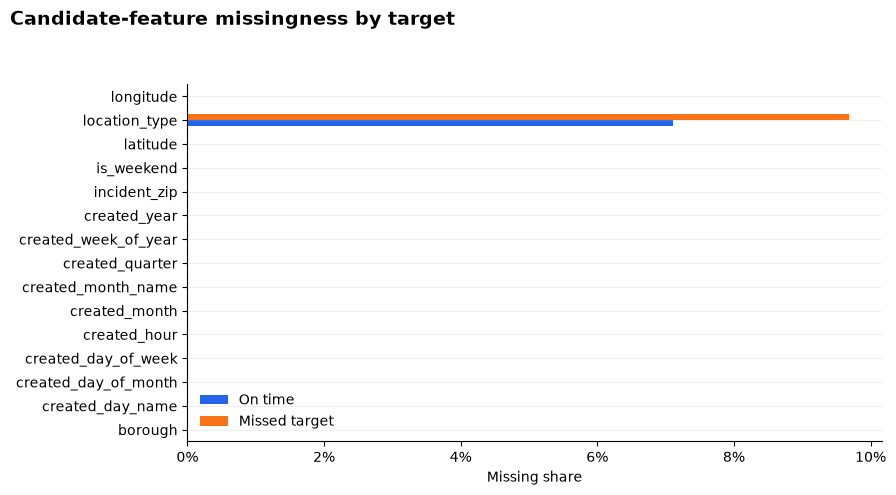

,feature_name,target_value,row_count,missing_count,missing_rate,absolute_difference_between_targets
0,borough,0,12792,0,0.000000,0.000000
1,borough,1,10907,0,0.000000,0.000000
2,location_type,0,12792,909,0.071060,0.025759
3,location_type,1,10907,1056,0.096819,0.025759
4,incident_zip,0,12792,1,0.000078,0.000014
5,incident_zip,1,10907,1,0.000092,0.000014
6,latitude,0,12792,1,0.000078,0.000014
7,latitude,1,10907,1,0.000092,0.000014
8,longitude,0,12792,1,0.000078,0.000014
9,longitude,1,10907,1,0.000092,0.000014


In [16]:
display(plot_missingness_by_target(TABLES))
plt.close()
TABLES['missingness_by_target.csv']


## 15. Missingness over time

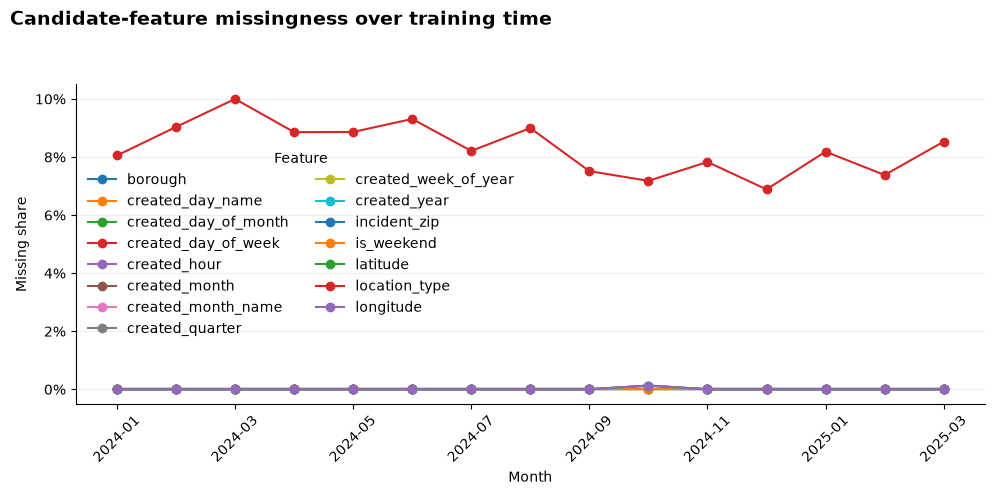

,feature_name,month,row_count,missing_count,missing_rate
0,borough,2024-01,1428,0,0.000000
1,borough,2024-02,1306,0,0.000000
2,borough,2024-03,1460,0,0.000000
3,borough,2024-04,1942,0,0.000000
4,borough,2024-05,1760,0,0.000000
5,borough,2024-06,1525,0,0.000000
6,borough,2024-07,1498,0,0.000000
7,borough,2024-08,1656,0,0.000000
8,borough,2024-09,1477,0,0.000000
9,borough,2024-10,1532,0,0.000000


In [17]:
display(plot_missingness_over_time(TABLES))
plt.close()
TABLES['missingness_by_month.csv'].head(30)


## 16. Categorical cardinality

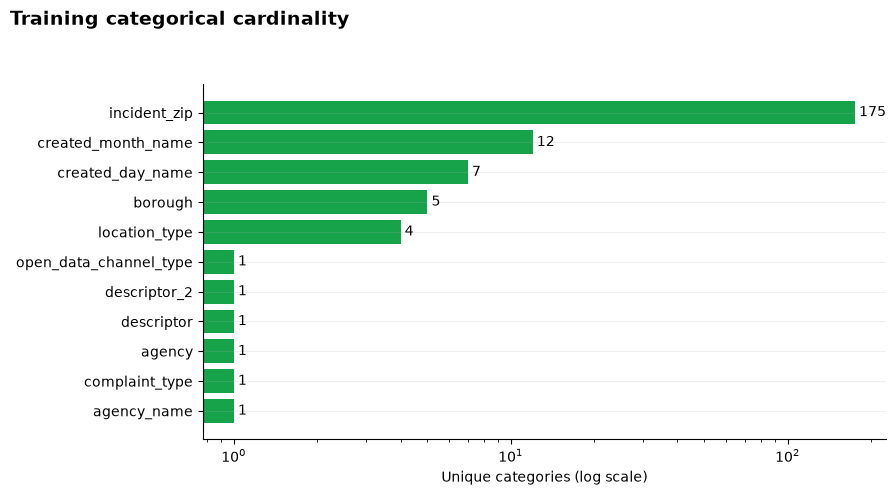

,feature_name,unique_count,missing_count,missing_rate,most_common_value,most_common_count,most_common_share,top_5_share,top_10_share,singleton_category_count,cardinality_band
0,borough,5,0,0.000000,BROOKLYN,12490,0.527026,1.000000,1.000000,0,LOW
1,location_type,4,1965,0.082915,Mixed Use,10360,0.437149,1.000000,1.000000,0,LOW
2,incident_zip,175,2,0.000084,11211,2235,0.094308,0.299253,0.431664,10,HIGH
3,created_day_name,7,0,0.000000,Thursday,4226,0.178320,0.782860,1.000000,0,LOW
4,created_month_name,12,0,0.000000,March,3031,0.127896,0.532892,0.874467,0,LOW
5,agency,1,0,0.000000,DSNY,23699,1.000000,1.000000,1.000000,0,ZERO_VARIANCE
6,agency_name,1,0,0.000000,Department of Sanitation,23699,1.000000,1.000000,1.000000,0,ZERO_VARIANCE
7,complaint_type,1,0,0.000000,Graffiti,23699,1.000000,1.000000,1.000000,0,ZERO_VARIANCE
8,descriptor,1,0,0.000000,Graffiti,23699,1.000000,1.000000,1.000000,0,ZERO_VARIANCE
9,descriptor_2,1,23699,1.000000,__MISSING__,23699,1.000000,1.000000,1.000000,0,ZERO_VARIANCE


In [18]:
display(plot_cardinality(TABLES))
plt.close()
TABLES['categorical_cardinality.csv']


## 17. Borough analysis
Missing and `Unspecified` values remain explicit and are never inferred.

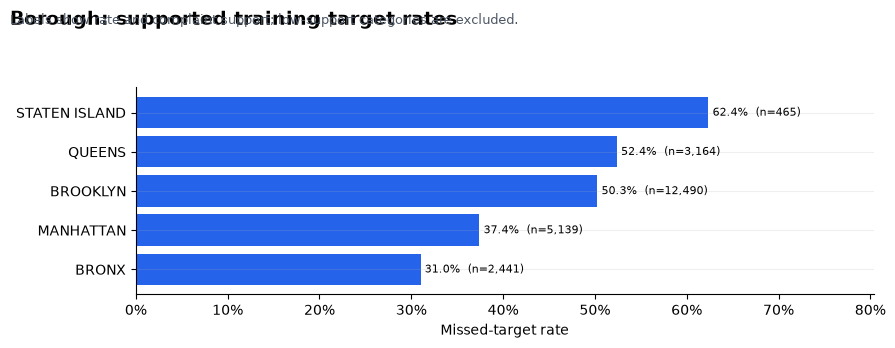

,feature_name,category_value,row_count,row_share,on_time_count,missed_count,missed_target_rate,difference_from_train_rate,minimum_support_passed,stability_warning
0,borough,BRONX,2441,0.103000,1684,757,0.310119,-0.150112,True,NONE
1,borough,BROOKLYN,12490,0.527026,6211,6279,0.502722,0.042492,True,NONE
2,borough,MANHATTAN,5139,0.216845,3216,1923,0.374197,-0.086033,True,NONE
3,borough,QUEENS,3164,0.133508,1506,1658,0.524020,0.063790,True,NONE
4,borough,STATEN ISLAND,465,0.019621,175,290,0.623656,0.163426,True,NONE


In [19]:
display(plot_categorical_target_rate(TABLES, 'borough'))
plt.close()
TABLES['categorical_target_rates.csv'].query("feature_name == 'borough'")


## 18. Location-type analysis

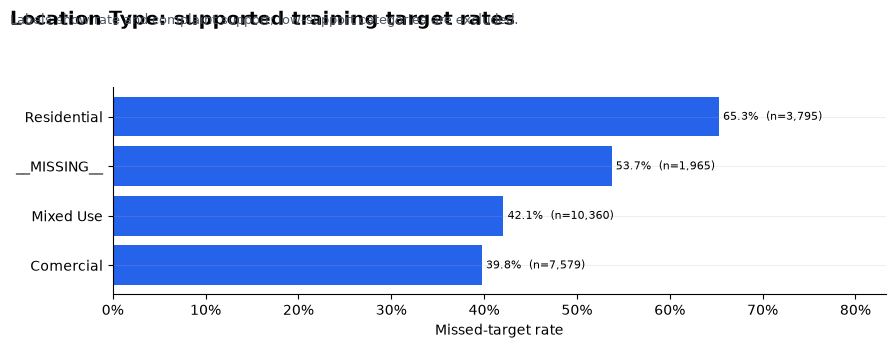

,feature_name,category_value,row_count,row_share,on_time_count,missed_count,missed_target_rate,difference_from_train_rate,minimum_support_passed,stability_warning
5,location_type,Comercial,7579,0.319803,4566,3013,0.397546,-0.062685,True,NONE
6,location_type,Mixed Use,10360,0.437149,6000,4360,0.420849,-0.039381,True,NONE
7,location_type,Residential,3795,0.160133,1317,2478,0.652964,0.192734,True,NONE
8,location_type,__MISSING__,1965,0.082915,909,1056,0.537405,0.077174,True,NONE


In [20]:
display(plot_categorical_target_rate(TABLES, 'location_type'))
plt.close()
TABLES['categorical_target_rates.csv'].query("feature_name == 'location_type'").head(25)


## 19. Incident-ZIP analysis
Incident ZIP remains a string and is not treated as a continuous number or target encoded.

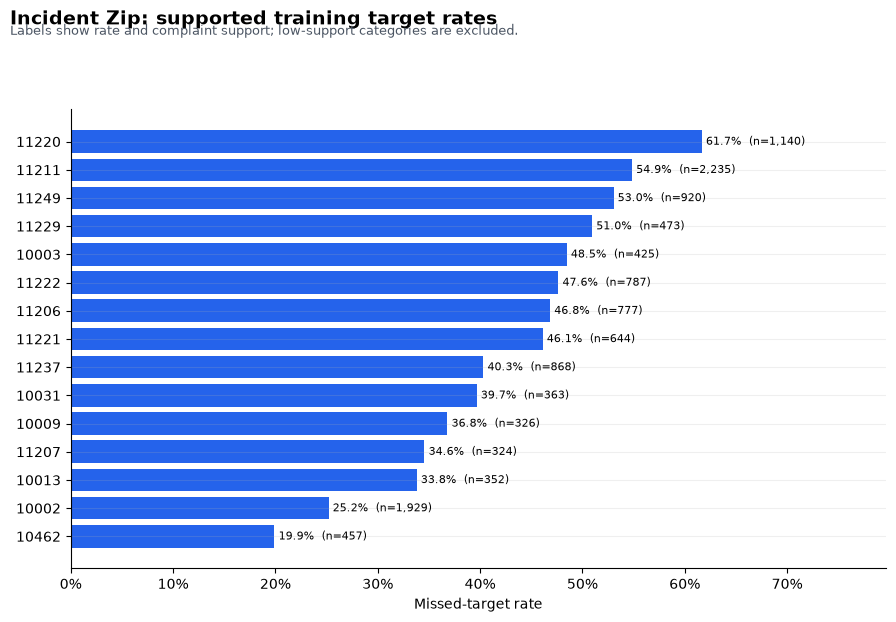

,feature_name,unique_count,missing_count,missing_rate,most_common_value,most_common_count,most_common_share,top_5_share,top_10_share,singleton_category_count,cardinality_band
2,incident_zip,175,2,0.000084,11211,2235,0.094308,0.299253,0.431664,10,HIGH


In [21]:
display(plot_categorical_target_rate(TABLES, 'incident_zip'))
plt.close()
TABLES['categorical_cardinality.csv'].query("feature_name == 'incident_zip'")


## 20. Scope-fixed and unusable fields

In [22]:
display(TABLES['zero_variance_columns.csv'])
display(TABLES['all_null_columns.csv'])

,feature_name,baseline_decision,decision_reason
0,agency,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
1,agency_name,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
2,complaint_type,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
3,descriptor,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
4,status,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Final...
5,open_data_channel_type,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
6,created_date_parse_failed,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Unkno...
7,closed_date_parse_failed,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Unkno...
8,due_date_parse_failed,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Unkno...
9,resolution_action_updated_date_parse_failed,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Unkno...


,feature_name,baseline_decision,decision_reason
0,descriptor_2,EXCLUDE_ALL_NULL,Deterministic priority: EXCLUDE_ALL_NULL; Inta...


## 21. Categorical feature-versus-target analysis
Low-support rates are marked and must not be presented as strong predictors.

In [23]:
TABLES['categorical_target_rates.csv'].head(30)

,feature_name,category_value,row_count,row_share,on_time_count,missed_count,missed_target_rate,difference_from_train_rate,minimum_support_passed,stability_warning
0,borough,BRONX,2441,0.103000,1684,757,0.310119,-0.150112,True,NONE
1,borough,BROOKLYN,12490,0.527026,6211,6279,0.502722,0.042492,True,NONE
2,borough,MANHATTAN,5139,0.216845,3216,1923,0.374197,-0.086033,True,NONE
3,borough,QUEENS,3164,0.133508,1506,1658,0.524020,0.063790,True,NONE
4,borough,STATEN ISLAND,465,0.019621,175,290,0.623656,0.163426,True,NONE
5,location_type,Comercial,7579,0.319803,4566,3013,0.397546,-0.062685,True,NONE
6,location_type,Mixed Use,10360,0.437149,6000,4360,0.420849,-0.039381,True,NONE
7,location_type,Residential,3795,0.160133,1317,2478,0.652964,0.192734,True,NONE
8,location_type,__MISSING__,1965,0.082915,909,1056,0.537405,0.077174,True,NONE
9,incident_zip,10001,53,0.002236,24,29,0.547170,0.086939,True,NONE


## 22. Numeric feature summary

In [24]:
TABLES['numeric_feature_summary.csv']

,feature_name,count,missing_count,missing_rate,mean,standard_deviation,minimum,maximum,q1,q3,iqr,infinite_count,p01,p05,p25,median,p75,p95,p99
0,latitude,23697,2,0.000084,40.715553,0.066369,40.525058,40.909987,40.681007,40.740567,0.059561,0,40.584050,40.604074,40.681007,40.714216,40.740567,40.844003,40.875810
1,longitude,23697,2,0.000084,-73.947373,0.055035,-74.237554,-73.702748,-73.987384,-73.918242,0.069142,0,-74.117774,-74.014518,-73.987384,-73.951304,-73.918242,-73.851879,-73.807965
2,created_day_of_month,23699,0,0.000000,15.950378,8.909575,1.000000,31.000000,8.000000,24.000000,16.000000,0,1.000000,2.000000,8.000000,16.000000,24.000000,30.000000,31.000000
3,created_week_of_year,23699,0,0.000000,23.972320,15.830893,1.000000,52.000000,10.000000,38.000000,28.000000,0,1.000000,2.000000,10.000000,22.000000,38.000000,51.000000,52.000000


## 23. Numeric distributions by target
Differences are descriptive associations, not causal effects.

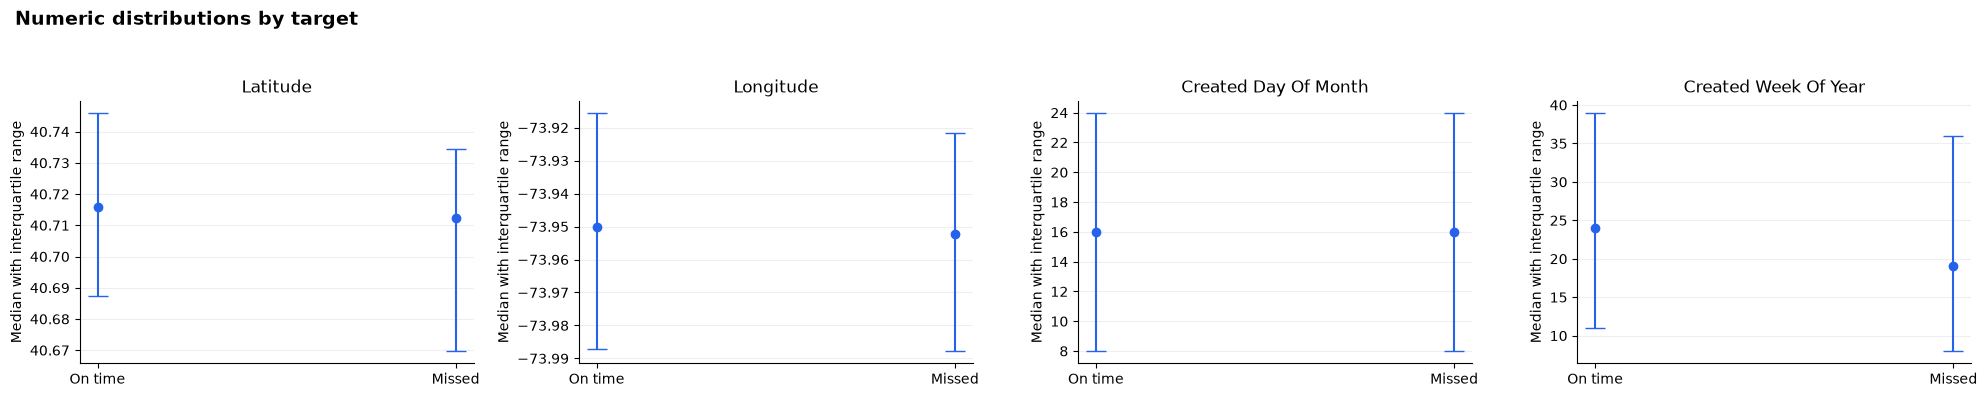

,feature_name,target_value,count,missing_rate,mean,median,standard_deviation,q1,q3,iqr,minimum,maximum
0,latitude,0,12791,0.000078,40.721631,40.716001,0.067514,40.687415,40.746053,0.058638,40.532812,40.905670
1,latitude,1,10906,0.000092,40.708423,40.712355,0.064276,40.669739,40.734488,0.064749,40.525058,40.909987
2,longitude,0,12791,0.000078,-73.944362,-73.950202,0.052685,-73.987112,-73.915479,0.071633,-74.220959,-73.702748
3,longitude,1,10906,0.000092,-73.950905,-73.952406,0.057470,-73.987754,-73.921753,0.066001,-74.237554,-73.705311
4,created_day_of_month,0,12792,0.000000,15.964431,16.000000,8.955369,8.000000,24.000000,16.000000,1.000000,31.000000
5,created_day_of_month,1,10907,0.000000,15.933896,16.000000,8.855946,8.000000,24.000000,16.000000,1.000000,31.000000
6,created_week_of_year,0,12792,0.000000,25.137899,24.000000,15.371080,11.000000,39.000000,28.000000,1.000000,52.000000
7,created_week_of_year,1,10907,0.000000,22.605299,19.000000,16.248217,8.000000,36.000000,28.000000,1.000000,52.000000


In [25]:
display(plot_numeric_by_target(TABLES))
plt.close()
TABLES['numeric_summary_by_target.csv']


## 24. Outlier definitions and governance
Domain-invalid, statistical-but-valid, and operational outliers are separate. No rows are removed or values clipped.

## 25. Geographic outlier analysis

In [26]:
TABLES['geographic_outlier_analysis.csv']

,finding,outlier_category,row_count,row_rate,recommended_action,governed_bounds
0,latitude_below_world_bound,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
1,latitude_above_world_bound,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
2,longitude_below_world_bound,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
3,longitude_above_world_bound,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
4,latitude_malformed,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
5,longitude_malformed,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
6,latitude_non_finite,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
7,longitude_non_finite,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
8,latitude_present_longitude_missing,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."
9,longitude_present_latitude_missing,DOMAIN_INVALID,0,0.0,INVESTIGATE_UPSTREAM,"lat=(-90.0, 90.0); lon=(-180.0, 180.0); nyc=(4..."


## 26. IQR and percentile diagnostics

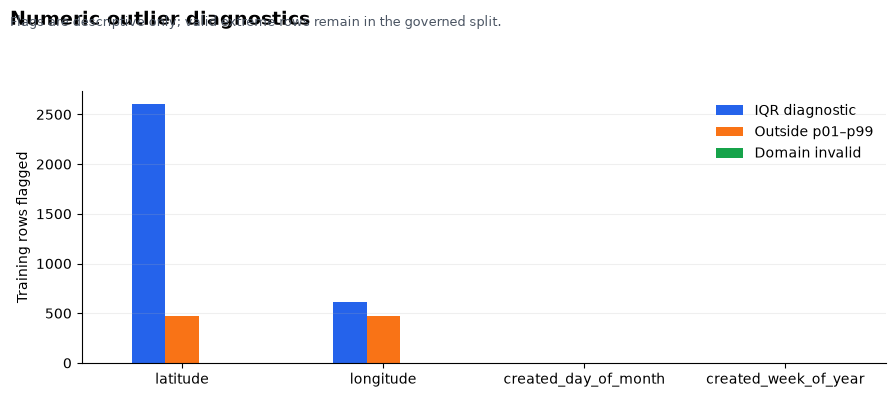

,feature_name,q1,q3,iqr,lower_iqr_fence,upper_iqr_fence,below_fence_count,above_fence_count,total_iqr_outlier_count,iqr_outlier_rate,p01_threshold,p99_threshold,below_p01_count,above_p99_count,domain_invalid_count,recommended_action,reason
0,latitude,40.681007,40.740567,0.059561,40.591665,40.829909,525,2076,2601,0.109751,40.58405,40.87581,237,237,0,RETAIN,Statistical extremes remain valid diagnostic o...
1,longitude,-73.987384,-73.918242,0.069142,-74.091098,-73.814529,291,319,610,0.025739,-74.117774,-73.807965,237,237,0,RETAIN,Statistical extremes remain valid diagnostic o...
2,created_day_of_month,8.000000,24.000000,16.000000,<NA>,<NA>,0,0,0,0.000000,<NA>,<NA>,0,0,0,NOT_APPLICABLE,IQR is not applied to cyclic or category-coded...
3,created_week_of_year,10.000000,38.000000,28.000000,<NA>,<NA>,0,0,0,0.000000,<NA>,<NA>,0,0,0,NOT_APPLICABLE,IQR is not applied to cyclic or category-coded...


In [27]:
display(plot_outlier_diagnostics(TABLES))
plt.close()
TABLES['numeric_outlier_analysis.csv']


## 27. Rare-category diagnostics

In [28]:
TABLES['rare_category_analysis.csv']

,feature_name,threshold_type,threshold_value,rare_category_count,train_rows_affected,train_row_share,validation_rows_affected,test_rows_affected,recommendation
0,borough,count,10.000,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
1,borough,count,25.000,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
2,borough,count,50.000,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
3,borough,share,0.001,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
4,borough,share,0.005,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
5,borough,share,0.010,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
6,location_type,count,10.000,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
7,location_type,count,25.000,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
8,location_type,count,50.000,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...
9,location_type,share,0.001,0,0,0.000000,0,0,DIAGNOSTIC_ONLY; evaluate train-fitted groupin...


## 28. Temporal operational outliers

In [29]:
TABLES['temporal_outlier_analysis.csv']

,metric,period,metric_value,row_count,classification,recommended_action
0,highest_volume_month,2024-12,2367.000000,2367,valid operational variation,RETAIN_PERIOD_AND_INVESTIGATE_CONTEXT
1,lowest_volume_month,2025-02,1260.000000,1260,valid operational variation,RETAIN_PERIOD_AND_INVESTIGATE_CONTEXT
2,largest_month_to_month_volume_change,2025-01,-1072.000000,1295,possible collection or policy change,RETAIN_PERIOD_AND_INVESTIGATE_CONTEXT
3,highest_target_rate_month,2025-01,0.610039,1295,valid operational variation,RETAIN_PERIOD_AND_INVESTIGATE_CONTEXT
4,lowest_target_rate_month,2024-11,0.336621,1622,valid operational variation,RETAIN_PERIOD_AND_INVESTIGATE_CONTEXT
5,largest_month_to_month_target_rate_change,2024-12,0.215554,2367,requires investigation,RETAIN_PERIOD_AND_INVESTIGATE_CONTEXT


## 29. Split target comparison
Test prevalence is disclosed for governance and temporal-drift context, not used for feature or transformation selection.

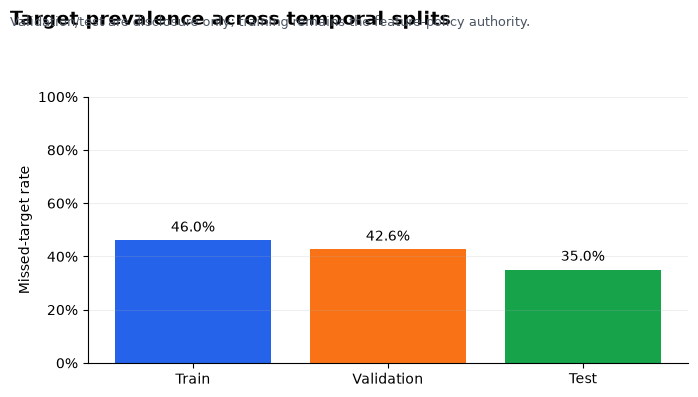

,split_name,row_count,on_time_count,missed_count,missed_target_rate,governance_use
0,train,23699,12792,10907,0.460230,feature discovery authority
1,validation,6762,3880,2882,0.426205,structural disclosure only; not feature selection
2,test,5499,3572,1927,0.350427,structural disclosure only; not feature selection


In [30]:
display(plot_split_target_rate(TABLES))
plt.close()
TABLES['split_target_comparison.csv']


## 30. Missingness drift

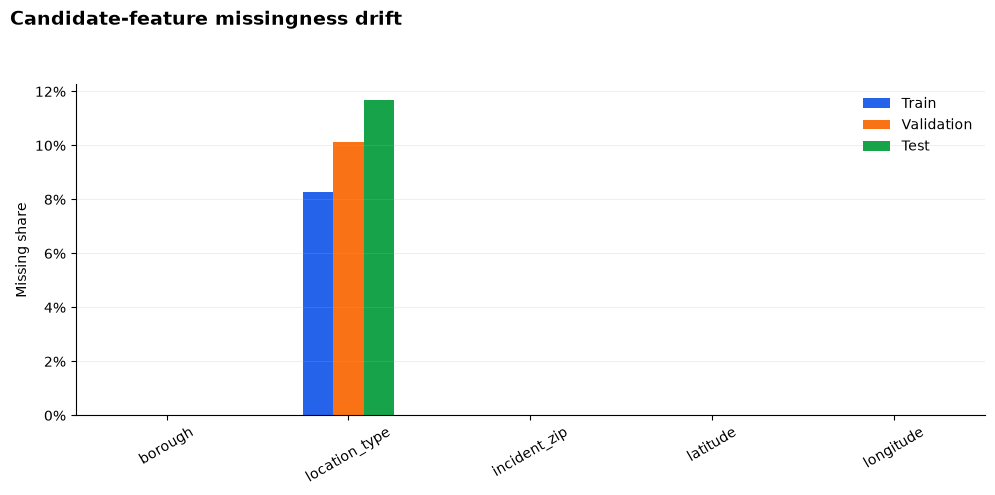

,feature_name,train_missing_rate,validation_missing_rate,test_missing_rate,train_validation_difference,train_test_difference,maximum_difference,interpretation
0,borough,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Structural disclosure only; train governs policy.
1,location_type,0.082915,0.101449,0.116748,0.018534,0.033834,0.033834,Structural disclosure only; train governs policy.
2,incident_zip,0.000084,0.000148,0.000000,0.000063,-0.000084,0.000084,Structural disclosure only; train governs policy.
3,latitude,0.000084,0.000148,0.000000,0.000063,-0.000084,0.000084,Structural disclosure only; train governs policy.
4,longitude,0.000084,0.000148,0.000000,0.000063,-0.000084,0.000084,Structural disclosure only; train governs policy.


In [31]:
display(plot_split_missingness(TABLES))
plt.close()
TABLES['split_missingness_comparison.csv']


## 31. Unseen-category analysis

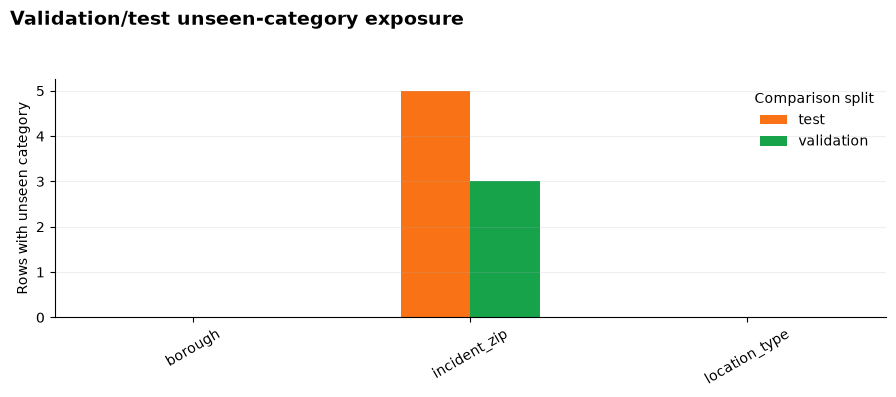

,feature_name,comparison_split,unseen_category_count,unseen_categories,rows_affected,row_share_affected,recommended_unknown_policy
0,borough,validation,0,,0,0.000000,TRAIN_FITTED_UNKNOWN_SAFE_ENCODING
1,borough,test,0,,0,0.000000,TRAIN_FITTED_UNKNOWN_SAFE_ENCODING
2,location_type,validation,0,,0,0.000000,TRAIN_FITTED_UNKNOWN_SAFE_ENCODING
3,location_type,test,0,,0,0.000000,TRAIN_FITTED_UNKNOWN_SAFE_ENCODING
4,incident_zip,validation,3,10118|10280|10307,3,0.000444,TRAIN_FITTED_UNKNOWN_SAFE_ENCODING
5,incident_zip,test,5,10278|10279|10307|11359|11360,5,0.000909,TRAIN_FITTED_UNKNOWN_SAFE_ENCODING


In [32]:
display(plot_unseen_categories(TABLES))
plt.close()
TABLES['unseen_categories.csv']


## 32. Numeric-range drift

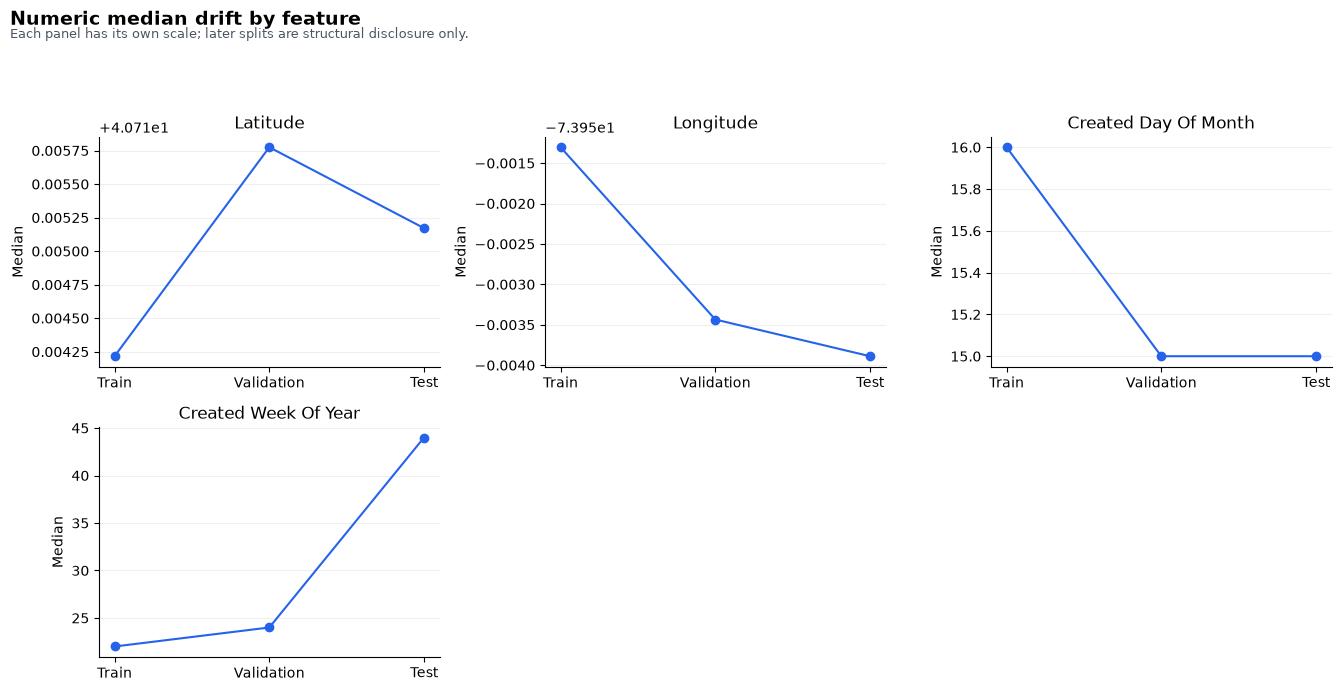

,feature_name,split_name,minimum,maximum,p01,median,p99,iqr,missing_rate,governance_use
0,latitude,train,40.525058,40.909987,40.584050,40.714216,40.875810,0.059561,0.000084,train authority
1,latitude,validation,40.503486,40.909803,40.582765,40.715775,40.879070,0.065363,0.000148,structural disclosure only
2,latitude,test,40.503486,40.909803,40.577255,40.715172,40.884742,0.051612,0.000000,structural disclosure only
3,longitude,train,-74.237554,-73.702748,-74.117774,-73.951304,-73.807965,0.069142,0.000084,train authority
4,longitude,validation,-74.250667,-73.702748,-74.126105,-73.953435,-73.792349,0.062123,0.000148,structural disclosure only
5,longitude,test,-74.250667,-73.723644,-74.130554,-73.953889,-73.812849,0.066581,0.000000,structural disclosure only
6,created_day_of_month,train,1.000000,31.000000,1.000000,16.000000,31.000000,16.000000,0.000000,train authority
7,created_day_of_month,validation,1.000000,31.000000,1.000000,15.000000,30.000000,14.000000,0.000000,structural disclosure only
8,created_day_of_month,test,1.000000,31.000000,1.000000,15.000000,31.000000,15.000000,0.000000,structural disclosure only
9,created_week_of_year,train,1.000000,52.000000,1.000000,22.000000,52.000000,28.000000,0.000000,train authority


In [33]:
display(plot_numeric_drift(TABLES))
plt.close()
TABLES['numeric_range_drift.csv']


## 33. Leakage and prediction-time availability
Step 4 remains authoritative; conditional fields are not silently promoted.

In [34]:
TABLES['leakage_audit.csv'][['column_name','authoritative_role','leakage_status','decision_reason']]

,column_name,authoritative_role,leakage_status,decision_reason
0,unique_key,IDENTIFIER,BLOCKED,Identifier invites memorisation and is not a m...
1,created_date,SAFE_FEATURE,SAFE,Available at creation; prefer derived calendar...
2,closed_date,TARGET_INPUT,BLOCKED,Closure outcome is unavailable at complaint cr...
3,due_date,TARGET_INPUT,BLOCKED,Target input whose creation-time timing and mu...
4,agency,SAFE_FEATURE,SAFE,Available at complaint creation.
5,agency_name,SAFE_FEATURE,SAFE,Available at complaint creation.
6,complaint_type,SAFE_FEATURE,SAFE,Available at complaint creation.
7,descriptor,CONDITIONAL_FEATURE,CONDITIONAL,Intake-time availability or later correction i...
8,descriptor_2,CONDITIONAL_FEATURE,CONDITIONAL,Intake-time availability or later correction i...
9,status,POST_CREATION_FIELD,BLOCKED,Final outcome or post-creation operational upd...


## 34. Baseline feature recommendation

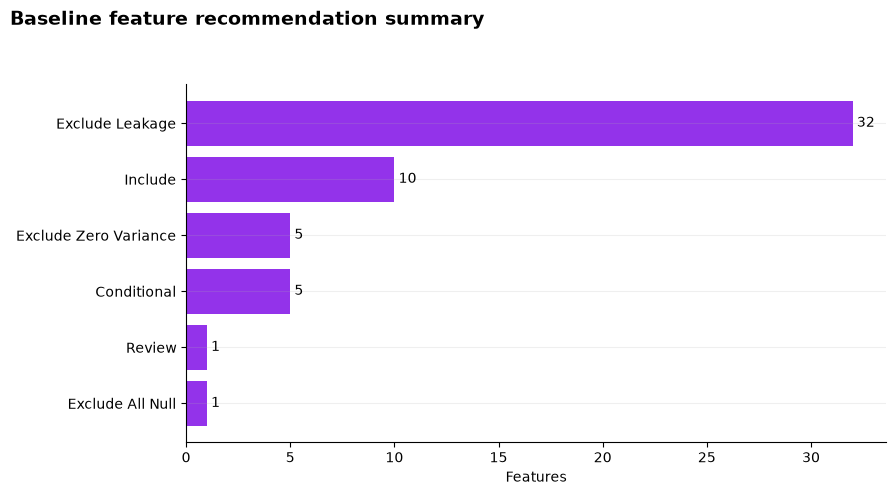

,feature_name,baseline_decision,decision_reason
0,unique_key,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Ident...
1,created_date,REVIEW,Deterministic priority: REVIEW; Available at c...
2,closed_date,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Closu...
3,due_date,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Targe...
4,agency,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
5,agency_name,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
6,complaint_type,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
7,descriptor,EXCLUDE_ZERO_VARIANCE,Deterministic priority: EXCLUDE_ZERO_VARIANCE;...
8,descriptor_2,EXCLUDE_ALL_NULL,Deterministic priority: EXCLUDE_ALL_NULL; Inta...
9,status,EXCLUDE_LEAKAGE,Deterministic priority: EXCLUDE_LEAKAGE; Final...


In [35]:
display(plot_recommendation_decisions(TABLES))
plt.close()
TABLES['baseline_feature_recommendation.csv'][['feature_name','baseline_decision','decision_reason']]


## 35. Transformation recommendation
All fitted recommendations specify train-only fitting and unchanged validation/test application.

In [36]:
TABLES['transformation_recommendation.csv']

,feature_name,data_type,recommended_missing_strategy,recommended_encoding,recommended_scaling,recommended_rare_category_policy,recommended_unknown_category_policy,recommended_outlier_treatment,fit_on,apply_to,reason
0,created_date,audit,NONE,NONE,NONE,NONE,NOT_APPLICABLE,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
1,borough,categorical,NONE,TRAIN_ONE_HOT_UNKNOWN_SAFE,NONE,NONE,MAP_TO___UNKNOWN__,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
2,incident_zip,categorical,EXPLICIT___MISSING___CANDIDATE,TRAIN_ONE_HOT_UNKNOWN_SAFE,NONE,EVALUATE_TRAIN_FITTED_RARE_GROUPING,MAP_TO___UNKNOWN__,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
3,latitude,numeric,TRAIN_MEDIAN_CANDIDATE,NONE,TRAIN_FITTED_FOR_LINEAR_MODELS,NONE,NOT_APPLICABLE,RETAIN_AND_MONITOR,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
4,longitude,numeric,TRAIN_MEDIAN_CANDIDATE,NONE,TRAIN_FITTED_FOR_LINEAR_MODELS,NONE,NOT_APPLICABLE,RETAIN_AND_MONITOR,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
5,location_type,categorical,EXPLICIT___MISSING___CANDIDATE,TRAIN_ONE_HOT_UNKNOWN_SAFE,NONE,NONE,MAP_TO___UNKNOWN__,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
6,created_hour,numeric,NONE,NONE,TRAIN_FITTED_FOR_LINEAR_MODELS,NONE,NOT_APPLICABLE,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
7,created_day_of_week,numeric,NONE,NONE,TRAIN_FITTED_FOR_LINEAR_MODELS,NONE,NOT_APPLICABLE,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
8,created_day_name,categorical,NONE,TRAIN_ONE_HOT_UNKNOWN_SAFE,NONE,NONE,MAP_TO___UNKNOWN__,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...
9,created_day_of_month,numeric,NONE,NONE,TRAIN_FITTED_FOR_LINEAR_MODELS,NONE,NOT_APPLICABLE,NOT_APPLICABLE,train,"validation,test",Recommendation only; Notebook 11 must fit any ...


## 36. Outlier recommendation

In [37]:
TABLES['outlier_recommendation.csv']

,feature_name,outlier_type,diagnostic_rule,lower_threshold,upper_threshold,outlier_count,outlier_rate,domain_invalid_count,recommended_action,decision_reason,fit_or_derive_on,apply_to
0,latitude,IQR_AND_PERCENTILE,train IQR multiplier=1.5; train p01/p99,40.591665,40.829909,2601,0.109751,0,RETAIN,Statistical extremes remain valid diagnostic o...,train,"validation,test without row removal"
1,longitude,IQR_AND_PERCENTILE,train IQR multiplier=1.5; train p01/p99,-74.091098,-73.814529,610,0.025739,0,RETAIN,Statistical extremes remain valid diagnostic o...,train,"validation,test without row removal"
2,created_day_of_month,IQR_AND_PERCENTILE,train IQR multiplier=1.5; train p01/p99,None,None,0,0.0,0,NOT_APPLICABLE,IQR is not applied to cyclic or category-coded...,train,"validation,test without row removal"
3,created_week_of_year,IQR_AND_PERCENTILE,train IQR multiplier=1.5; train p01/p99,None,None,0,0.0,0,NOT_APPLICABLE,IQR is not applied to cyclic or category-coded...,train,"validation,test without row removal"
4,borough,RARE_CATEGORY,configured count/share candidates; no threshol...,<NA>,<NA>,<NA>,<NA>,0,RETAIN_AND_MONITOR,Rare groups remain diagnostic until train-fitt...,train,"validation,test unknown-safe"
5,location_type,RARE_CATEGORY,configured count/share candidates; no threshol...,<NA>,<NA>,<NA>,<NA>,0,RETAIN_AND_MONITOR,Rare groups remain diagnostic until train-fitt...,train,"validation,test unknown-safe"
6,incident_zip,RARE_CATEGORY,configured count/share candidates; no threshol...,<NA>,<NA>,<NA>,<NA>,0,RETAIN_AND_MONITOR,Rare groups remain diagnostic until train-fitt...,train,"validation,test unknown-safe"


## 37. Output reconciliation

In [38]:
TABLES['output_reconciliation.csv']

,check_name,left_value,right_value,status
0,split_rows_reconcile,35960,35960,PASS
1,target_counts_reconcile,35960,35960,PASS
2,required_table_inventory,34,34,PASS
3,no_source_rows_removed,35960,35960,PASS
4,train_only_fitted_recommendations,train,train,PASS


## 38. Source immutability verification

In [39]:
verify_source_unchanged(result.source)
pd.Series({'source_hashes_and_mtimes_unchanged': True})

source_hashes_and_mtimes_unchanged    True
dtype: bool

## 39. Known limitations
The source is a later-state operational snapshot, temporal rates shift, and creation-time availability remains unresolved for conditional geography fields. Rare and outlier thresholds remain diagnostics.

## 40. Step 9A completion decision

In [ ]:
integrity_pass = TABLES['eda_integrity_checks.csv']['status'].ne('FAIL').all()
reconciliation_pass = TABLES['output_reconciliation.csv']['status'].eq('PASS').all()
pd.Series({
    'integrity': 'PASS' if integrity_pass else 'FAIL',
    'reconciliation': 'PASS' if reconciliation_pass else 'FAIL',
    'step_9a_decision': 'COMPLETE' if integrity_pass and reconciliation_pass else 'NOT_COMPLETE',
    'model_ready': False,
})

integrity               PASS
reconciliation          PASS
step_9a_decision    COMPLETE
model_ready            False
dtype: object